# **φ⁶ generalization test** — Allen-Cahn + quintic, full-diagram $\ell$-loop vs simulation (d = 1)

A fresh test of whether the model-independent spatial pipeline handles a **new, higher-degree
interaction vertex** with no special-casing.  Same machinery as the φ⁴ notebook, new physics:

$$\partial_t\phi = D\,\partial_x^2\phi - \mu\phi - \lambda\phi^3 - \gamma\phi^5 + \eta,\qquad
  \langle\eta(x,t)\eta(x',t')\rangle = 2T\,\delta(x-x')\delta(t-t').$$

The $-\gamma\phi^5$ force is a **confining sextic potential** $V=\tfrac{\mu}{2}\phi^2+\tfrac{\lambda}{4}\phi^4+\tfrac{\gamma}{6}\phi^6$
(bounded below for $\gamma>0$; the deterministic saddle is still $\phi^*=0$).

**Key point — γ first contributes at 2 loops.**  The new interaction is a $\tilde\phi\phi^5$ vertex of
*total degree 6*.  `compute_cumulants` auto-picks `taylor_order = max(k + 2·max_ell, 2)`, so this vertex
is only captured at `max_ell ≥ 2` (`taylor_order = 2 + 2·2 = 6`):

* at **`max_ell = 1`** the result is *identical* to pure φ⁴ — γ is truncated away;
* at **`max_ell = 2`** the $\tilde\phi\phi^5$ vertex enters as a **2-loop tadpole** ($(5-1)/2 = 2$ loops),
  so γ first corrects the correlator there.

So the meaningful generalization test is **`MAX_ELL = 2`** (the default below).  Nothing here is
φ⁶-specific in the code — the same `enumerate → Symanzik → causal chambers → integrate` path runs.

*(The canonical standalone theory is `theories/allen_cahn_quintic_1d_subcritical_infinite.theory.py`;
the builder is inlined below so you can tweak it.)*

In [1]:
import os, sys, time
# --- depth-robust repo root: walk up until we find the 'pipeline' package ---
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))   # daedalus engine
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ so relative data paths resolve as before
import numpy as np
import matplotlib.pyplot as plt
import daedalus as dd
from models.spatial_field_phi6_1d_sim import simulate, equal_time_correlator

mu, D, T, lam, gamma = 1.0, 1.0, 1.0, 0.1, 0.1   # mass, diffusion, noise temp, φ³ coupling, φ⁵ coupling

# Load the canonical standalone theory through the shared engine.
# theories/allen_cahn_quintic_1d_subcritical_infinite.theory.py reproduces the
# φ⁶ Allen-Cahn builder VERBATIM (same parameters, action, equation, boundary,
# initial); the loaded model exposes the d-prefixed fluctuation field 'dphi'.
model, mod = dd.load_theory('allen_cahn_quintic_1d_subcritical_infinite')

def order_label(ell):
    # cumulative loop label: 0->'tree', 1->'tree + 1-loop', 2->'tree + 1-loop + 2-loop'
    return ('tree' if ell == 0 else
            'tree + ' + ' + '.join('%d-loop' % j for j in range(1, ell + 1)))

## 0. Choose the order — `k` and `ℓ`

* **`MAX_ELL`** — the loop order $\ell$.  **Default 2**, because γ (the φ⁵ coupling) first appears at
  2 loops; at `0`/`1` you get tree / the pure-φ⁴ 1-loop tadpole (γ invisible).
  *Cost:* tree/1-loop are seconds; **2-loop is slower than the φ⁴ case** — the $\tilde\phi\phi^5$ vertex
  adds diagrams on top of the φ⁴ 2-loop set, so expect **a few minutes**.
* **`K_EXTERNAL`** — the correlator order $k$.  v1 supports the **two-point** correlator $k=2$.
* **`VERBOSE`** — `True` prints the staged `[1/7]…[7/7]` pipeline for each order; watch the
  `[6/7]` enumeration gain the `ell=2` $\tilde\phi\phi^5$ diagrams.

We evaluate the **equal-time** correlator ($\tau=0$).

In [2]:
# ============================  CHOOSE THE ORDER  ============================
MAX_ELL    = 2      # loop order ℓ:  0 = tree,  1 = +1-loop (= pure φ⁴),  2 = +2-loop (γ enters; ~min)
K_EXTERNAL = 2      # correlator order k:  2 = two-point ⟨φφ⟩ (v1 supports k=2)
VERBOSE    = True   # True ⇒ print the staged [1/7]…[7/7] pipeline for each order
# ===========================================================================

if K_EXTERNAL != 2:
    raise NotImplementedError(
        "v1 implements the k=2 two-point correlator; k>2 needs the multi-point "
        "external Fourier transform (future work).")

xs = np.linspace(0.0, 6.0, 25)                       # output separations χ ≥ 0
fund = {'mu': mu, 'D': D, 'lam': lam, 'gamma': gamma, 'T': T}
# Build the run config through the shared engine.  The loaded model's field is the
# d-prefixed fluctuation 'dphi'; the two-point correlator legs are both that field
# (equivalent to the original [('phi',1),('phi',1)]).  Equal-time only (τ=0).
cfg = dd.Config(k=K_EXTERNAL, max_ell=MAX_ELL,
                external_fields=[('dphi', 1), ('dphi', 1)],
                fundamental=fund, chi_grid=xs,
                tau_max=0.0, tau_step=1.0, verbose=VERBOSE)
orders = list(range(0, MAX_ELL + 1))
print('will compute orders ℓ =', orders, ' at k =', K_EXTERNAL,
      ' (γ = %.3f first enters at ℓ=2)' % gamma)

will compute orders ℓ = [0, 1, 2]  at k = 2  (γ = 0.100 first enters at ℓ=2)


## 1. Theory: every order up to `MAX_ELL` through `compute_cumulants`

For each $\ell$, `compute_cumulants(max_ell=ℓ)` enumerates all diagrams up to that loop order and runs
the full-diagram integrator on each live one.  At $\ell=2$ the new $\tilde\phi\phi^5$ vertex appears —
that is the generalization being tested.  (ℓ=0 and ℓ=1 are γ-independent, so they reproduce the φ⁴
numbers exactly.)

In [3]:
# ONE call at the top loop order gives the WHOLE cumulative progression: the
# highest-ℓ run already contains every lower order (res['C_tau_x_by_order'] is
# {0: tree, 1: +1-loop, …, MAX_ELL} cumulative C(χ,τ)).  No need to re-run per ℓ.
t0 = time.time()
res = dd.run(model, cfg, mod)
by_order = res.get('C_tau_x_by_order') or (res.get('spatial_info') or {}).get('C_by_order', {})
mid = res['C_tau_x'].shape[0] // 2               # τ = 0 row
si = res.get('spatial_info', {}) or {}

# Shim: re-export the exact legacy names the downstream sim/diagnostic/plot cells use.
curves = {}
for ell in orders:
    c = np.real(np.asarray(by_order[ell]))
    curves[ell] = c[mid] if c.ndim == 2 else c
    print('%-26s C(0,0) = %.4f   live diagrams = %s   (%.0fs)'
          % (order_label(ell), curves[ell][0],
             si.get('n_live_diagrams', '—'), time.time() - t0))

C_tree = curves[0]
C_best = curves[MAX_ELL]
print('\nvariance C(0,0) by cumulative order:')
for ell in orders:
    print('   %-26s = %.4f' % (order_label(ell), curves[ell][0]))

[1/7] FieldTheory.expand (taylor_order=6)...


[expand-cache] saved order=6 → saved_theories/1d_stochastic_phi_6_allen_cahn_quintic_infinite/expand_taylor6.sobj
=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM
      vtypes: 4, sources: 1 (NoiseSourceType: 0)

      ── MF action (bigrade ≤1 in each index; vanishes at saddle) ──
      bigrade (1, 0):
        phit1  *  (gamma*phistar1^5 + lam*phistar1^3 + mu*phistar1)

      ── Free action (1,1) bilinear sector ──
        phit1·dphi1  *  (5*gamma*phistar1^4 + 3*lam*phistar1^2 - D*Laplacian + Dt + mu)

      ── Interaction action (total degree ≥ 2, excluding (1,1)) ──
      bigrade (1,2):
        phit1·dphi1^2  *  (10*gamma*phistar1^3 + 3*lam*phistar1)
      bigrade (1,3):
        phit1·dphi1^3  *  (10*gamma*phistar1^2 + lam)
      bigrade (1,4):
        phit1·dphi1^4  *  (5*gamma*phistar1)
      bigrade (1,5):
        phit1·


      ── K_ft (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
        [0,0] = 5*gamma*phistar1^4 + 3*lam*phistar1^2 - D*Laplacian + mu + I*omega
      symbolic inverse/adj/det took 0.02s
      ── spatial propagator (d=1, bc=infinite) ──
        G_tx[phit1,dphi1]: A(mass)=5*gamma*phistar1^4 + 3*lam*phistar1^2 + mu, B(diff)=D

      ── D(ω) = det(K_ft) ──
        5*gamma*phistar1^4 + 3*lam*phistar1^2 - D*Laplacian + mu + I*omega

      ── G_ft = K_ft⁻¹ (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
        [0,0] = 1/(5*gamma*phistar1^4 + 3*lam*phistar1^2 - D*Laplacian + mu + I*omega)

      ── adj_ft = G_ft · D(ω) (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
        [0,0] = 1

      ── D_delta = lim_{ω→∞} G_ft (instantaneous) (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
[propagator] Cached to: saved_theories/1d_stochastic_phi_

      certify: max rel = 1.83e-16 (tol 1e-08) -> PASS
[6/7] (spatial) Enumerate prediagrams + typed diagrams → classify coefficient factors → map to C-stack descriptors (max_ell=2)...


        ell=0: 1 typed diagram(s); 𝒮(Γ)·prefactor(s) = ['2*T']
        ell=1: 4 typed diagram(s); 𝒮(Γ)·prefactor(s) = ['16*(10*gamma*phistar1^3 + 3*lam*phistar1)^2*T^2', '-12*(10*gamma*phistar1^2 + lam)*T^2', '8*(10*gamma*phistar1^3 + 3*lam*phistar1)^2*T^2', '8*(10*gamma*phistar1^3 + 3*lam*phistar1)^2*T^2']
        ell=2: 73 typed diagram(s); 𝒮(Γ)·prefactor(s) = ['-192*(10*gamma*phistar1^3 + 3*lam*phistar1)^2*(10*gamma*phistar1^2 + lam)*T^3', '-192*(10*gamma*phistar1^3 + 3*lam*phistar1)^2*(10*gamma*phistar1^2 + lam)*T^3', '-192*(10*gamma*phistar1^3 + 3*lam*phistar1)^2*(10*gamma*phistar1^2 + lam)*T^3', '128*(10*gamma*phistar1^3 + 3*lam*phistar1)^4*T^3', '128*(10*gamma*phistar1^3 + 3*lam*phistar1)^4*T^3', '128*(10*gamma*phistar1^3 + 3*lam*phistar1)^4*T^3', '128*(10*gamma*phistar1^3 + 3*lam*phistar1)^4*T^3', '128*(10*gamma*phistar1^3 + 3*lam*phistar1)^4*T^3', '128*(10*gamma*phistar1^3 + 3*lam*phistar1)^4*T^3', '128*(10*gamma*phistar1^3 + 3*lam*phistar1)^4*T^3', '128*(10*gamma*phistar1^3 +

[spatial] done — C(x,τ) ready; tree-mode certified=True (max rel 1.8e-16)
tree                       C(0,0) = 0.5000   live diagrams = 7   (26s)
tree + 1-loop              C(0,0) = 0.4625   live diagrams = 7   (26s)
tree + 1-loop + 2-loop     C(0,0) = 0.3769   live diagrams = 7   (26s)

variance C(0,0) by cumulative order:
   tree                       = 0.5000
   tree + 1-loop              = 0.4625
   tree + 1-loop + 2-loop     = 0.3769


## 2. Simulation of the SPDE

A pseudo-spectral Euler–Maruyama (ETD1) integration of the φ⁶ Langevin equation on a periodic ring;
the equal-time correlator is averaged over snapshots after burn-in.  The $-\gamma\phi^5$ force is
confining for $\gamma>0$, so the run is stable.

In [4]:
snaps, x_grid, meta = simulate(L=40.0, N=256, mu=mu, D=D, lam=lam, gamma=gamma, T=T,
                               n_steps=120000, burn_in=20000, record_every=20, seed=1)
Cx_full = equal_time_correlator(snaps)               # C[m] at separation m·dx, length N
half = len(x_grid) // 2 + 1
xc, Cx = x_grid[:half], Cx_full[:half]               # one period side, x ≥ 0
print('sim variance C(0,0) = %.4f' % Cx[0])
print('theory variance C(0,0) by cumulative order:')
for ell in orders:
    print('   %-26s = %.4f' % (order_label(ell), curves[ell][0]))

sim variance C(0,0) = 0.4300
theory variance C(0,0) by cumulative order:
   tree                       = 0.5000
   tree + 1-loop              = 0.4625
   tree + 1-loop + 2-loop     = 0.3769


## 3. Compare: theory orders vs simulation

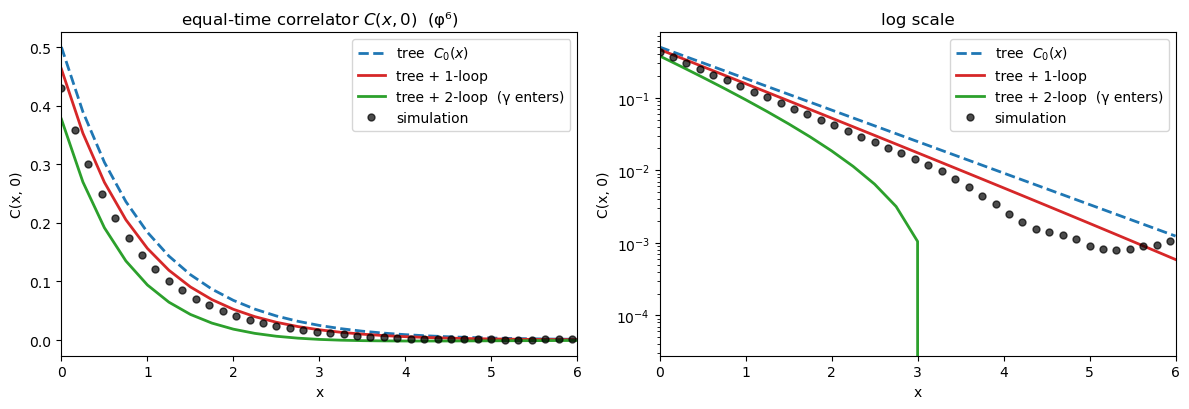

distance |sim − theory| at x=0  (sim variance = 0.4300):
   tree                       : |Δ| = 0.0700
   tree + 1-loop              : |Δ| = 0.0325
   tree + 1-loop + 2-loop     : |Δ| = 0.0531
   (ℓ=0,1 are γ-independent; the ℓ=2 step is where the φ⁵ vertex acts)


In [5]:
styles = {0: ('--', 'C0', r'tree  $C_0(x)$'),
          1: ('-',  'C3', 'tree + 1-loop'),
          2: ('-',  'C2', 'tree + 2-loop  (γ enters)')}

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a in ax:
    for ell in orders:
        ls, col, lab = styles[ell]
        a.plot(xs, curves[ell], ls, lw=2, color=col, label=lab)
    a.plot(xc, Cx, 'o', ms=5, color='k', alpha=0.7, label='simulation')
    a.set_xlabel(r'$\chi$'); a.set_ylabel('C(χ, 0)'); a.set_xlim(0, xs.max())
ax[0].set_title('equal-time correlator $C(χ,0)$  (φ⁶)'); ax[0].legend()
ax[1].set_yscale('log'); ax[1].set_title('log scale'); ax[1].legend()
plt.tight_layout(); plt.show()

# how much closer to the sim does each added loop order get at χ = 0 (the variance)?
sim0 = Cx[0]
print('distance |sim − theory| at χ=0  (sim variance = %.4f):' % sim0)
for ell in orders:
    print('   %-26s : |Δ| = %.4f' % (order_label(ell), abs(sim0 - curves[ell][0])))
if MAX_ELL >= 2:
    print('   (ℓ=0,1 are γ-independent; the ℓ=2 step is where the φ⁵ vertex acts)')

## Summary

This notebook reuses the **same** full-diagram integrator as the φ⁴ case on a theory with a brand-new
$\tilde\phi\phi^5$ (degree-6) interaction vertex — no model-specific code.  If the pipeline generalizes,
you should see:

* **ℓ=0, ℓ=1** reproduce the pure-φ⁴ numbers (tree $0.5$, 1-loop $\approx 0.4625$ at these params) —
  γ is correctly absent below 2 loops;
* **ℓ=2** picks up the $\tilde\phi\phi^5$ 2-loop tadpole (visible in the `[6/7]` enumeration as new
  `ell=2` diagrams), shifting the correlator by an amount that scales with γ.

**Knobs:** `gamma` (the φ⁵ coupling — its effect is $O(\gamma)$ at 2 loops; increase it to make the
ℓ=2 shift more visible), `lam`, `mu`, `D`, and `MAX_ELL`.  Set `MAX_ELL=1` to confirm the φ⁴-identical
behavior; `MAX_ELL=2` to exercise the new vertex.  Derivative/∇ vertices remain future work.